## Top Skills for Top 3 Data Science Job

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import ast

# load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# clean-up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x:
        ast.literal_eval(x)
        if pd.notna(x)
        else(x)
)

In [2]:
# filter only the 'United States'
df_us = df[df['job_country'] == 'United States'].copy()

df_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","[sql, python, java, sql server, gcp, bigquery,...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","[sql, python, r, mongodb, mongodb, sql server,...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."


In [3]:
# explode the job_skills, so we can count it later
df_us_exploded = df_us.explode('job_skills')

df_us_exploded[['job_title_short', 'job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,NaN
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,NaN
785705,Data Analyst,sql
785705,Data Analyst,python


In [4]:
# count the skills
df_us_skills = df_us_exploded.groupby(['job_skills', 'job_title_short']).size()

df_us_skills

job_skills  job_title_short          
airflow     Business Analyst               38
            Cloud Engineer                 27
            Data Analyst                  387
            Data Engineer                4716
            Data Scientist               1166
                                         ... 
zoom        Machine Learning Engineer       5
            Senior Data Analyst            50
            Senior Data Engineer           30
            Senior Data Scientist          25
            Software Engineer              16
Length: 1870, dtype: int64

In [5]:
type(df_us_skills)

pandas.Series

In [6]:
# change the df_us_skills to dataframe
df_us_skills = df_us_skills.reset_index(name='skill_count')

df_us_skills

,job_skills,job_title_short,skill_count
0,airflow,Business Analyst,38
1,airflow,Cloud Engineer,27
2,airflow,Data Analyst,387
3,airflow,Data Engineer,4716
4,airflow,Data Scientist,1166
...,...,...,...
1865,zoom,Machine Learning Engineer,5
1866,zoom,Senior Data Analyst,50
1867,zoom,Senior Data Engineer,30
1868,zoom,Senior Data Scientist,25


In [7]:
# sort values by skill_count
df_us_skills.sort_values(by='skill_count', ascending=False, inplace=True)

df_us_skills

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [8]:
# top 3 job by demand, convert to a list and assign it to variable
job_titles = df['job_title_short'].value_counts().head(3).index.to_list()

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

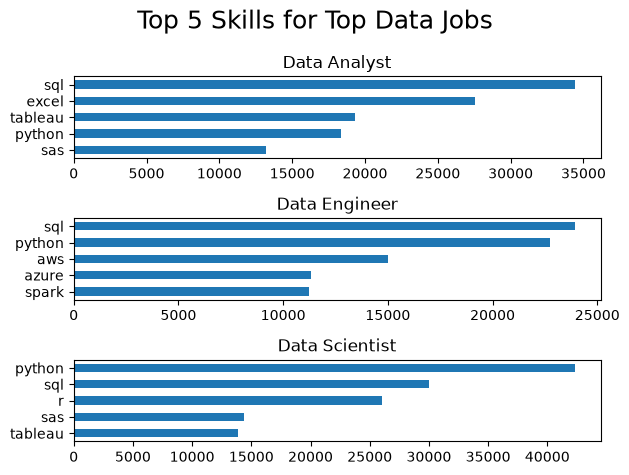

In [9]:
# top 3 job list
job_titles = df['job_title_short'].value_counts().head(3).index.to_list()

# create a subplot for each of job_title
fig, ax = plt.subplots(len(job_titles), 1)

# create function, 
# filter the top 5 skills by the top job
for i, job_titles in enumerate(job_titles):
    df_plot = df_us_skills[df_us_skills['job_title_short'] == job_titles].head(5)
    df_plot.plot(
        kind='barh', 
        x='job_skills', 
        y='skill_count', 
        ax=ax[i],
        title=job_titles
    )
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

# clean the plot
fig.suptitle('Top 5 Skills for Top Data Jobs', fontsize=18)
fig.tight_layout()

plt.show()


In [10]:
# we gonna make the count, in %
# first we need the total count by job_title
df_job_count = df_us['job_title_short'].value_counts().reset_index(name='job_total')

df_job_count

,job_title_short,job_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [11]:
# merge it with df_us_skills, so we can see the whole things
df_skills_pct = pd.merge(df_us_skills, df_job_count, how='left', on='job_title_short')

df_skills_pct

,job_skills,job_title_short,skill_count,job_total
0,python,Data Scientist,42379,58830
1,sql,Data Analyst,34452,67816
2,sql,Data Scientist,30034,58830
3,excel,Data Analyst,27519,67816
4,r,Data Scientist,26022,58830
...,...,...,...,...
1865,vue.js,Business Analyst,1,7382
1866,arch,Business Analyst,1,7382
1867,asana,Machine Learning Engineer,1,921
1868,no-sql,Machine Learning Engineer,1,921


In [12]:
# make a new column for pct %
df_skills_pct['skill_pct'] = 100 * (df_skills_pct['skill_count'] / df_skills_pct['job_total'])

df_skills_pct

,job_skills,job_title_short,skill_count,job_total,skill_pct
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


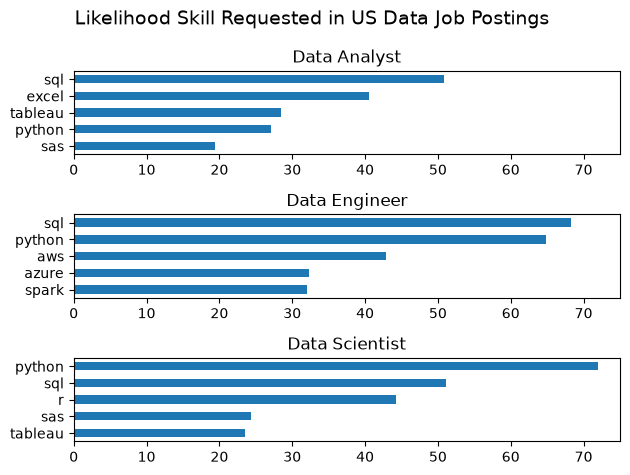

In [13]:
# top 3 job list
job_titles = df['job_title_short'].value_counts().head(3).index.to_list()

# create a subplot for each of job_title
fig, ax = plt.subplots(len(job_titles), 1)

# create function, set it to the pct
for i, job_titles in enumerate(job_titles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == job_titles].head(5)
    df_plot.plot(
        kind='barh', 
        x='job_skills', 
        y='skill_pct', 
        ax=ax[i],
        title=job_titles
    )
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 75)

# clean the plot
fig.suptitle('Likelihood Skill Requested in US Data Job Postings ', fontsize=14)
fig.tight_layout()

plt.show()

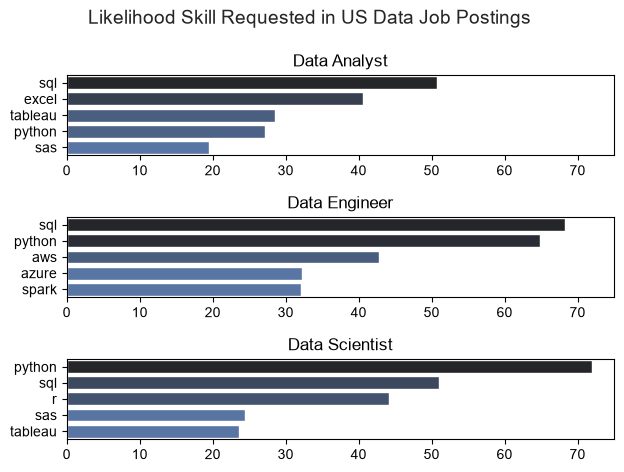

In [14]:
# try using seaborn instead
job_titles = df['job_title_short'].value_counts().head(3).index.to_list()
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_titles in enumerate(job_titles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == job_titles].head(5)
    sns.barplot(
        data=df_plot, 
        x='skill_pct', 
        y='job_skills', 
        ax=ax[i], 
        hue='skill_pct', 
        palette='dark:b_r'
    )
    ax[i].set_title(job_titles)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 75)

fig.suptitle('Likelihood Skill Requested in US Data Job Postings ', fontsize=14)
fig.tight_layout()

plt.show()

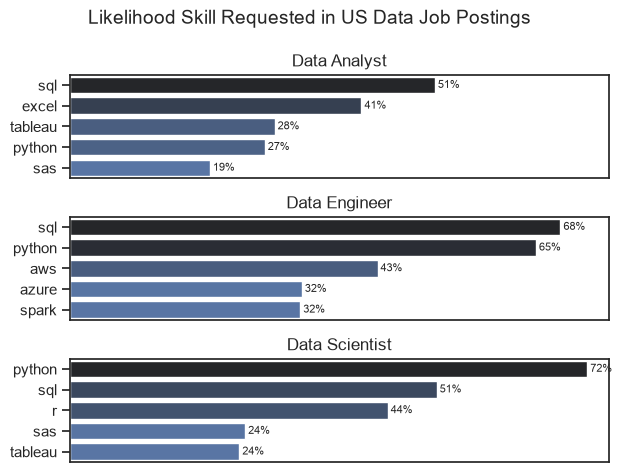

In [15]:
# we gonna put label inside the plot for each skill pct %
job_titles = df['job_title_short'].value_counts().head(3).index.to_list()
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_titles in enumerate(job_titles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == job_titles].head(5)
    sns.barplot(
        data=df_plot, 
        x='skill_pct', 
        y='job_skills', 
        ax=ax[i], 
        hue='skill_pct', 
        palette='dark:b_r'
    )
    ax[i].set_title(job_titles)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 75)

    # here's the label
    for n, v in enumerate(df_plot['skill_pct']):
        ax[i].text(v, n, f'{v: .0f}%', va='center', fontsize=8) 

    ax[i].set_xticks([])   

fig.suptitle('Likelihood Skill Requested in US Data Job Postings ', fontsize=14)
fig.tight_layout()

plt.show()